In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [77]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [78]:
data=load_breast_cancer()
X=data.data
y=data.target

print("Dataset Shape:", X.shape)
print("Classes:", np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [79]:
X_train, X_test, y_train, y_test= train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

In [85]:
mle_model=LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42
)

mle_model.fit(X_train, y_train)
y_pred_mle = mle_model.predict(X_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [86]:
map_l2=LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

map_l2.fit(X_train, y_train)
y_pred_l2 = map_l2.predict(X_test)

In [87]:
map_l1=LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

map_l1.fit(X_train, y_train)
y_pred_l1 = map_l1.predict(X_test)

In [88]:
def evaluate(model_name, y_true, y_pred):
    print("=========================")
    print(model_name)
    print("=========================")

    print("Accuracy:", accuracy_score(y_true,y_pred))
    print("precision:", precision_score(y_true,y_pred))
    print("recall:", recall_score(y_true,y_pred))
    print("f1 score:", f1_score(y_true,y_pred))

    print("\n confusion matrix")
    print(confusion_matrix(y_true, y_pred))
    

In [89]:
evaluate ("MLE", y_test, y_pred_mle)

MLE
Accuracy: 0.7456140350877193
precision: 0.8307692307692308
recall: 0.75
f1 score: 0.7883211678832117

 confusion matrix
[[31 11]
 [18 54]]


In [90]:
evaluate("L2", y_test, y_pred_l2)
evaluate("L1", y_test, y_pred_l1)

L2
Accuracy: 0.631578947368421
precision: 0.631578947368421
recall: 1.0
f1 score: 0.7741935483870968

 confusion matrix
[[ 0 42]
 [ 0 72]]
L1
Accuracy: 0.4824561403508772
precision: 0.6031746031746031
recall: 0.5277777777777778
f1 score: 0.562962962962963

 confusion matrix
[[17 25]
 [34 38]]


In [91]:
print("Number of zero coefficients")
print("MLE:", np.sum(mle_model.coef_[0]==0))
print("map l2:", np.sum(map_l2.coef_[0]==0))
print("map l1:", np.sum(map_l1.coef_[0]==0))

Number of zero coefficients
MLE: 0
map l2: 0
map l1: 20


In [92]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 score"
])

models=[
    ("MLE",mle_model, y_pred_mle),
    ("map l2:",map_l2, y_pred_l2),
    ("map l1:",map_l1 , y_pred_l1)
]
for name, model, pred in models:
     results.loc[len(results)]=[
    name,
    accuracy_score(y_test, pred),
    precision_score(y_test, pred),
    recall_score(y_test, pred),
    f1_score(y_test, pred)
]

print(results)

     Model  Accuracy  Precision    Recall  F1 score
0      MLE  0.745614   0.830769  0.750000  0.788321
1  map l2:  0.631579   0.631579  1.000000  0.774194
2  map l1:  0.482456   0.603175  0.527778  0.562963


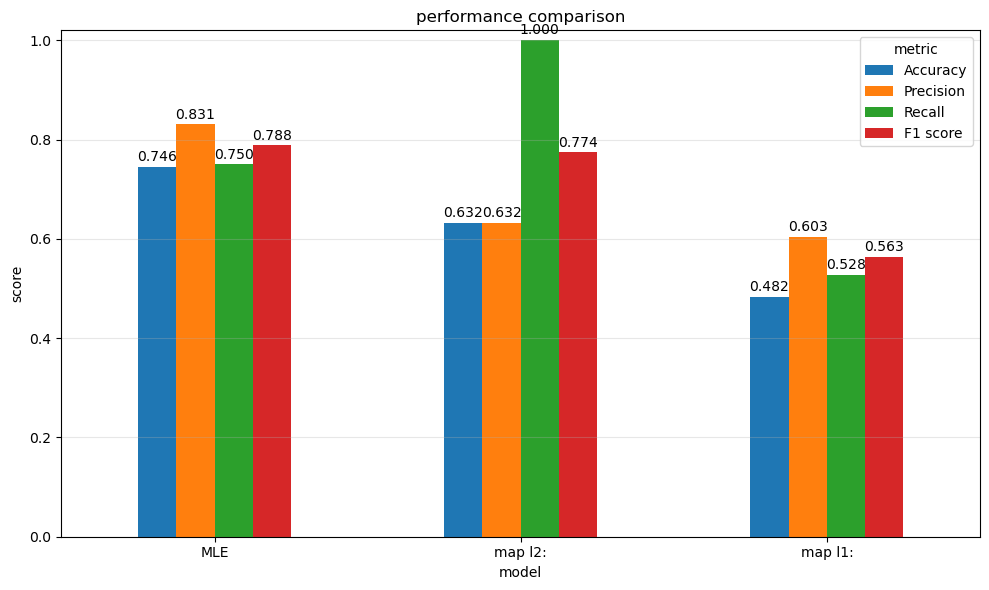

In [93]:
ax=results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title('performance comparison')
plt.xlabel('model')
plt.ylabel('score')
plt.ylim(0, 1.02)

plt.xticks(rotation=0)
plt.legend(title="metric")
plt.grid(axis="y", alpha = 0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)
    
plt.tight_layout()
plt.show()

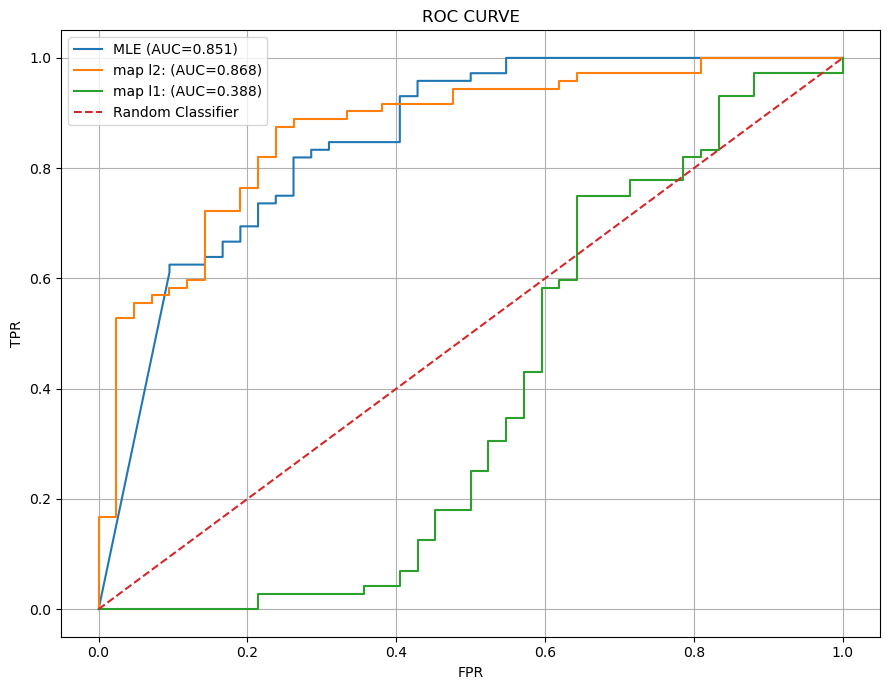

In [94]:
plt.figure(figsize=(9,7))
for name,model,pred in models:
    y_prob= model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds= roc_curve(y_test, y_prob)
    roc_auc= auc(fpr,tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.title('ROC CURVE')
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

